In [20]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [21]:
X,Y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

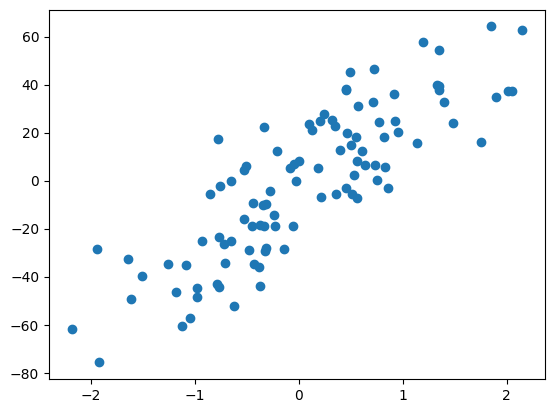

In [22]:
plt.scatter(X,Y)

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=23)

In [24]:
class GDRegressor:
  def __init__(self,learning_rate,epochs):
    self.m = 100
    self.b = -120
    self.lr = learning_rate
    self.epochs = epochs

  def fit(self,X,Y):
    self.losses = []
    for i in range(self.epochs):
      y_pred = self.m * X.ravel() + self.b
      loss = np.mean((Y - y_pred) ** 2)
      self.losses.append(loss)

      loss_slope_b = -2 * np.sum(Y - self.m*X.ravel() - self.b)
      loss_slope_m = -2* np.sum((Y - self.m*X.ravel() - self.b)*X.ravel())

      self.b = self.b - (self.lr*loss_slope_b)
      self.m = self.m - (self.lr * loss_slope_m)
    print(self.m,self.b)

  def predict(self,X):
    return self.m* X + self.b


In [25]:
gd = GDRegressor(0.001,100)
gd.fit(X_train,Y_train)

28.034122458823735 -3.539931894309669


In [26]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2Score = r2_score(Y_test,y_pred)
print(r2Score)

0.5712616520941273


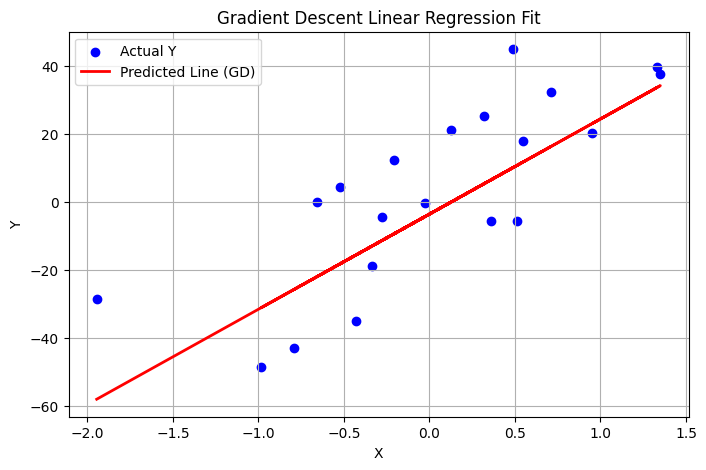

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, Y_test, color='blue', label='Actual Y')
plt.plot(X_test, y_pred, color='red', label='Predicted Line (GD)', linewidth=2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Gradient Descent Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.show()

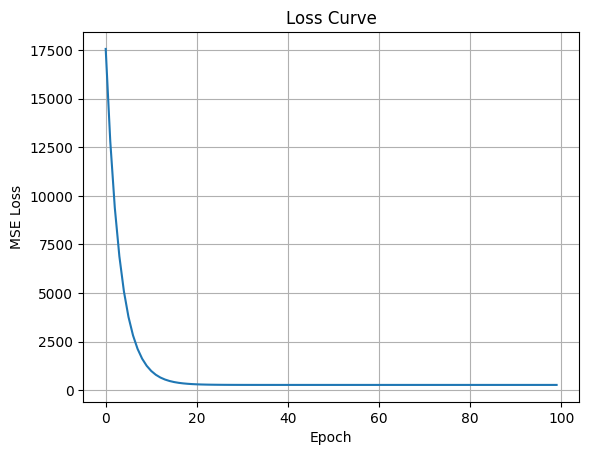

In [28]:
plt.plot(gd.losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss Curve")
plt.grid(True)
plt.show()